## Tarea 2
Programa Experto en Inteligencia Artificial con Python  
ML3009 - Series de Tiempo  
Estudiante: Natalia Bonilla Villalobos.  
**Conceptos fundamentales de las Series de Tiempo**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
- [Ejercicio 2](#ej2)
- [Ejercicio 3](#ej3)

In [1]:
import math
import warnings
import statistics
import numpy as np
import pandas as pd
from scipy import stats, signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import shapiro
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')  # Oculta warnings en la salida
from abc import  ABCMeta, abstractmethod

from numpy import corrcoef

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Modelos Predictivos

In [2]:
class BasePrediccion(metaclass = ABCMeta):    
  @abstractmethod
  def forecast(self):
    pass

class Prediccion(BasePrediccion):
  def __init__(self, modelo):
    self.__modelo = modelo
  
  @property
  def modelo(self):
    return self.__modelo  
  
  @modelo.setter
  def modelo(self, modelo):
    if(isinstance(modelo, Modelo)):
      self.__modelo = modelo
    else:
      warnings.warn('El objeto debe ser una instancia de Modelo.')
  
class meanfPrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.coef)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class naivePrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.coef)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class snaivePrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    pos = 0
    for i in range(steps):
      if pos >= len(self.modelo.coef):
        pos = 0
      res.append(self.modelo.coef[pos])
      pos = pos + 1
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class driftPrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.ts[-1] + self.modelo.coef * i)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class BaseModelo(metaclass = ABCMeta):    
  @abstractmethod
  def fit(self):
    pass

class Modelo(BaseModelo):
  def __init__(self, ts):
    self.__ts = ts
    self._coef = None
  
  @property
  def ts(self):
    return self.__ts  
  
  @ts.setter
  def ts(self, ts):
    if(isinstance(ts, pd.core.series.Series)):
      if(ts.index.freqstr != None):
        self.__ts = ts
      else:
        warnings.warn('ERROR: No se indica la frecuencia de la serie de tiempo.')
    else:
      warnings.warn('ERROR: El parámetro ts no es una instancia de serie de tiempo.')
  
  @property
  def coef(self):
    return self._coef
  
class meanf(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = statistics.mean(self.ts)
    res = meanfPrediccion(self)
    return(res)

class naive(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = self.ts[-1]
    res = naivePrediccion(self)
    return(res)

class snaive(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self, h = 1):
    self._coef = self.ts.values[-h:]
    res = snaivePrediccion(self)
    return(res)

class drift(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = (self.ts[-1] - self.ts[0]) / len(self.ts)
    res = driftPrediccion(self)
    return(res)

## Cálculo de errores

In [3]:
class ts_error:
  def __init__(self, preds, real, nombres = None):
    self.__preds = preds
    self.__real = real
    self.__nombres = nombres
  
  @property
  def preds(self):
    return self.__preds
  
  @preds.setter
  def preds(self, preds):
    if(isinstance(preds, pd.core.series.Series) or isinstance(preds, numpy.ndarray)):
      self.__preds = [preds]
    elif(isinstance(preds, list)):
      self.__preds = preds
    else:
      warnings.warn('ERROR: El parámetro preds debe ser una serie de tiempo o una lista de series de tiempo.')
  
  @property
  def real(self):
    return self.__real
  
  @real.setter
  def real(self, real):
    self.__real = real
  
  @property
  def nombres(self):
    return self.__nombres
  
  @nombres.setter
  def nombres(self, nombres):
    if(isinstance(nombres, str)):
      nombres = [nombres]
    if(len(nombres) == len(self.__preds)):
      self.__nombres = nombres
    else:
      warnings.warn('ERROR: Los nombres no calzan con la cantidad de métodos.')
  
  def RSS(self):
    res = []
    for pred in self.preds:
      res.append(sum((pred - self.real)**2))
    return(res)
  
  def MSE(self):
    return([pred / len(self.real) for pred in self.RSS()])
  
  def RMSE(self):
    return([math.sqrt(pred) for pred in self.MSE()])
  
  def RE(self):
    res = []
    for pred in self.preds:
      res.append(sum(abs(self.real - pred)) / sum(abs(self.real)))
    return(res)
  
  def CORR(self):
    res = []
    for pred in self.preds:
      corr = corrcoef(self.real, pred)[0, 1]
      res.append(0 if math.isnan(corr) else corr)
    return(res)
  
  def df_errores(self):
    res = pd.DataFrame({'MSE': self.MSE(), 'RMSE': self.RMSE(), 'RE': self.RE(), 'CORR': self.CORR()})
    if(self.nombres is not None):
      res.index = self.nombres
    return(res)
  
  def __escalar(self):
    res = self.df_errores()
    for nombre in res.columns.values:
      res[nombre] = res[nombre] - min(res[nombre])
      res[nombre] = res[nombre] / max(res[nombre]) * 100
    return(res)
  
  def plot_errores(self):
    plt.figure(figsize=(8, 8))
    df = self.__escalar()
    if(len(df) == 1):
      df.loc[0] = 100
    
    N = len(df.columns.values)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]
    
    ax = plt.subplot(111, polar = True)
    
    ax.set_theta_offset(math.pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], df.columns.values)
    
    ax.set_rlabel_position(0)
    plt.yticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"], color = "grey", size = 10)
    plt.ylim(-10, 110)
    
    for i in df.index.values:
      p = df.loc[i].values.tolist()
      p = p + p[:1]
      ax.plot(angles, p, linewidth = 1, linestyle = 'solid', label = i)
      ax.fill(angles, p, alpha = 0.1)
    
    plt.legend(loc = 'best')
    plt.show()
    
  def plotly_errores(self):
    df = self.__escalar()
    etqs = df.columns.values.tolist()
    etqs = etqs + etqs[:1]
    if(len(df) == 1):
      df.loc[0] = 100
    
    fig = go.Figure()
    
    for i in df.index.values:
      p = df.loc[i].values.tolist()
      p = p + p[:1]
      fig.add_trace(go.Scatterpolar(
        r = p, theta = etqs, fill = 'toself', name = i
      ))
    
    fig.update_layout(
      polar = dict(
        radialaxis = dict(
          visible = True,
          range=[-10, 110]
      ))
    )
    
    return(fig)


## Periodograma

In [4]:
class Periodograma:
  def __init__(self, ts):
    self.__ts = ts
    self.__freq, self.__spec = signal.periodogram(ts)
  
  @property
  def ts(self):
    return self.__ts
  
  @property
  def freq(self):
    return self.__freq
  
  @property
  def spec(self):
    return self.__spec
  
  def mejor_freq(self, best = 3):
    res = np.argsort(-self.spec)
    res = res[res != 1][0:best]
    return(self.freq[res])
  
  def mejor_periodos(self, best = 3):
    return(1 / self.mejor_freq(best))
  
  def plot_periodograma(self, best = 3):
    res = self.mejor_freq(best)
    plt.plot(self.freq, self.spec, color = "darkgray")
    for i in range(best):
      plt.axvline(x = res[i], label = "Mejor " + str(i + 1), ls = '--', c = np.random.rand(3))
    plt.legend(loc = "best")
    plt.show()
  
  def plotly_periodograma(self, best = 3):
    res = self.mejor_freq(best)
    fig = go.Figure()
    no_plot = fig.add_trace(
      go.Scatter(x = self.freq, y = self.spec, 
                 mode = 'lines+markers', line_color = 'darkgray')
    )
    for i in range(best):
      v = np.random.rand(3)
      color = "rgb(" + str(v[0]) + ", " + str(v[1]) + ", " + str(v[2]) + ")"
      fig.add_vline(x = res[i], line_width = 2, line_dash = "dash", 
                    annotation_text = "Mejor " + str(i + 1), 
                    line_color = color)
    
    return(fig)

<a id="ej1"></a>
# Ejercicio 1 
[30 puntos] El archivo `velocidad_viento.csv` contiene la medición de la velocidad del viento cada 10 minutos. Con la tabla realice lo siguiente:
- a) Transforme la serie de datos por cada 10 minutos en una serie de datos promediados por hora.
- b) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).
- c) Convierta a serie de tiempo utilizando la variable `VelocidadViento`.
- d) Verifique la normalidad de la serie de tiempo (las diferencias). Debe de probar la normalidad utilizando las 3 formas vistas en clase.
- e) Convierta a serie de tiempo y realice una descomposición de la serie de tiempo.
- f) Determine y grafique los periodos más importantes.
- g) Usando 1 día para pruebas y el resto de fechas para entrenamiento genere modelos utilizando los métodos del `Promedio`, `Ingenuo`, `Estacional Ingenuo` y el de `Desvío`, luego grafique en un solo gráfico la serie de entrenamiento, la serie de prueba y el resultado de la predicción de cada uno de los modelos anteriores.
- h) Con un gráfico mida el error y determine cuál modelo es el mejor.
- i) Con el mejor modelo encontrado en el punto anterior genere la predicción de un día, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

[↑ Volver al Menú](#menu)


### Preparación de los datos

In [5]:
velocidad_viento = pd.read_csv('../../w1/h1/velocidad_viento.csv', delimiter=';', decimal=',')
velocidad_viento

,Fecha,VelocidadViento
0,2020-01-01 06:00:00,5.4772348750000015
1,2020-01-01 06:10:00,6.362752373684209
2,2020-01-01 06:20:00,6.522534785
3,2020-01-01 06:30:00,5.636349794444443
4,2020-01-01 06:40:00,5.720647215789473
...,...,...
12741,2020-03-30 23:10:00,3.53344485
12742,2020-03-30 23:20:00,3.261231389473684
12743,2020-03-30 23:30:00,3.33183875
12744,2020-03-30 23:40:00,3.284468215789474


In [6]:
velocidad_viento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12746 entries, 0 to 12745
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Fecha            12746 non-null  object
 1   VelocidadViento  12746 non-null  object
dtypes: object(2)
memory usage: 199.3+ KB


In [7]:
velocidad_viento['VelocidadViento'] = velocidad_viento['VelocidadViento'].astype('float64')
velocidad_viento['Fecha'] = velocidad_viento['Fecha'].astype('datetime64[ns]')
velocidad_viento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12746 entries, 0 to 12745
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            12746 non-null  datetime64[ns]
 1   VelocidadViento  12746 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 199.3 KB


### Parte 1
- a) Transforme la serie de datos por cada 10 minutos en una serie de datos promediados por hora.

In [8]:
velocidad_viento_1h = velocidad_viento.set_index('Fecha').resample('1H').mean()

In [9]:
velocidad_viento_1h = velocidad_viento_1h.reset_index(inplace=False)
velocidad_viento_1h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154 entries, 0 to 2153
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            2154 non-null   datetime64[ns]
 1   VelocidadViento  2131 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 33.8 KB


In [10]:
# función para verificar si hay fechas faltantes en la columna de fecha, con una frecuencia dada
def hay_fechas_faltantes(datos, col_name_date, frequency):
    df = datos.copy()
    start_date = df[col_name_date].min()
    last_date = df[col_name_date].max()
    date_range = pd.date_range(start=start_date, end=last_date, freq=frequency).to_list()
    
    # verificacion mas robusta, probar. 1
    # faltantes = [x for x in date_range if x not in df[col_name_date].to_list()]
    # otro test, probar. 3
    faltantes = pd.Index(date_range).difference(df[col_name_date]) 
    if len(faltantes) == 0: # probar. 2
#     if len(df) >= len(date_range):
            print(f"No, no hay valores faltantes en la columna '{col_name_date}'.")
    else:
        print(f"Sí, hay fechas faltantes con una diferencia en la columna '{col_name_date}' de: {len(df) - len(date_range)}")
   
    return {
        'date_range': date_range,
        'faltantes': faltantes
    }

### Parte 2
- b) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).

In [11]:
sc_velocidad_viento = hay_fechas_faltantes(velocidad_viento_1h, col_name_date='Fecha', frequency='H')

No, no hay valores faltantes en la columna 'Fecha'.


In [12]:
velocidad_viento_1h.isna().sum()

Fecha               0
VelocidadViento    23
dtype: int64

In [13]:
# función para rellenar las fechas faltantes, derivadas de la función anterior
def rellenar_fechas(datos, col_name_date, serie_completa):
    df = datos.copy()
    # asegurar datetime
    # df[col_name_date] = pd.to_datetime(df[col_name_date])
    df[col_name_date] = df[col_name_date].astype('datetime64[ns]')
    
    fechas_faltantes = [x for x in serie_completa if x not in df[col_name_date].to_list()]
    print('Primeras 5 filas:\n', fechas_faltantes[:5])
    
    completando_serie = pd.concat([df, pd.DataFrame({'Fecha': fechas_faltantes})], ignore_index = True) # Se añaden las fechas faltantes al final 
    completando_serie.sort_values(by = col_name_date, inplace = True) # Se ordenan las fechas de forma ascendente

    print('\nValores faltantes: ', completando_serie[col_name_date].isnull().sum())

    return completando_serie

# velocidad_viento_rellena = rellenar_fechas(velocidad_viento, col_name_date='Fecha', serie_completa=serie_completa['date_range'])

In [14]:
def to_serie_tiempo(datos, col_name_date, col_name_values, frequency):
    df = datos.copy()
    df.set_index(col_name_date, inplace=True)
    serie_tiempo = df[col_name_values].asfreq(frequency)    
    return serie_tiempo

In [15]:
# # Imputa valores faltantes utilizando un suavizado móvil, basado en vecinos cercanos (rolling mean).
# # si to_serie es True, se devuelve la serie de tiempo, si no, se devuelve el dataframe con los valores imputados.
# def imputar_valores_faltantes_suavizados(datos_rellenados, col_name_values, size, to_serie=False, frequency=None, col_name_date=None): # VelocidadViento
#     df = datos_rellenados.copy()

#     suavizado = (
#         df[col_name_values]
#         .rolling(window=size, center=True, min_periods=1)
#         .mean()
#     )

#     df[col_name_values] = df[col_name_values].fillna(suavizado)
    
#     if to_serie is True:
#         df = to_serie_tiempo(df, col_name_date, col_name_values, frequency)
#         # (datos, col_name_date, col_name_values, frequency)
    
#     return df

In [16]:
# # Imputa valores faltantes utilizando un suavizado móvil, basado en vecinos cercanos (rolling mean).
# # si to_serie es True, se devuelve la serie de tiempo, si no, se devuelve el dataframe con los valores imputados.
def imputar_valores_faltantes_suavizados(datos_rellenados, col_name_values, size, to_serie=False, frequency=None, col_name_date=None):
    df = datos_rellenados.copy()

    suavizado = (
        df[col_name_values].rolling(window=size, center=True, min_periods=1).mean()
    )

    # Primera imputacion
    df[col_name_values] = (df[col_name_values].fillna(suavizado))

    # Verificar si aun quedan NaN
    faltantes = df[col_name_values].isna().sum()

    if faltantes > 0:
        print(f'Aún quedan {faltantes} valores faltantes. Aplicando interpolación...')
        df[col_name_values] = (df[col_name_values].interpolate(method='linear'))
    else:
        print(f'Todos los valores faltantes fueron imputados con suavizado de {size} datos.')

    # convertir a serie temporal
    if to_serie:
        df = to_serie_tiempo(df, col_name_date, col_name_values, frequency)

    return df

In [17]:
vv_1h_ts_imputacion = imputar_valores_faltantes_suavizados(velocidad_viento_1h, col_name_values='VelocidadViento', size=3, to_serie=True, frequency='H', col_name_date='Fecha')
vv_1h_ts_imputacion[:5]

Aún quedan 18 valores faltantes. Aplicando interpolación...


Fecha
2020-01-01 06:00:00    5.896444
2020-01-01 07:00:00    5.847268
2020-01-01 08:00:00    5.444347
2020-01-01 09:00:00    5.109854
2020-01-01 10:00:00    5.420360
Freq: h, Name: VelocidadViento, dtype: float64

In [18]:
# imputamos los valores faltantes con la media de la columna, para ser valorada como serie de tiempo completa, sin valores faltantes.
# def imputar_valores_faltantes(datos_rellenados, datos_originales, col_name_values): # VelocidadViento
#     df = datos_rellenados.copy()
#     prom_velocidad = datos_originales[col_name_values].mean()
#     df.loc[df[col_name_values].isna(), col_name_values] = prom_velocidad
#     return df

# velocidad_viento_df = imputar_valores_faltantes(velocidad_viento_rellena, velocidad_viento, 'VelocidadViento')
# velocidad_viento_df.head(5)

### Parte 3
- c) Convierta a serie de tiempo utilizando la variable `VelocidadViento`.

In [19]:
vv_1h_ts_imputacion[:10]

Fecha
2020-01-01 06:00:00    5.896444
2020-01-01 07:00:00    5.847268
2020-01-01 08:00:00    5.444347
2020-01-01 09:00:00    5.109854
2020-01-01 10:00:00    5.420360
2020-01-01 11:00:00    6.484427
2020-01-01 12:00:00    7.171225
2020-01-01 13:00:00    7.788046
2020-01-01 14:00:00    6.613341
2020-01-01 15:00:00    6.843382
Freq: h, Name: VelocidadViento, dtype: float64

### Parte 4
- d) Verifique la normalidad de la serie de tiempo (las diferencias). Debe de probar la normalidad utilizando las 3 formas vistas en clase.

#### **Comparación de gráficos de los residuos**

In [20]:
np.diff(vv_1h_ts_imputacion)[:5]

array([-0.04917643, -0.40292018, -0.3344938 ,  0.31050611,  1.06406775])

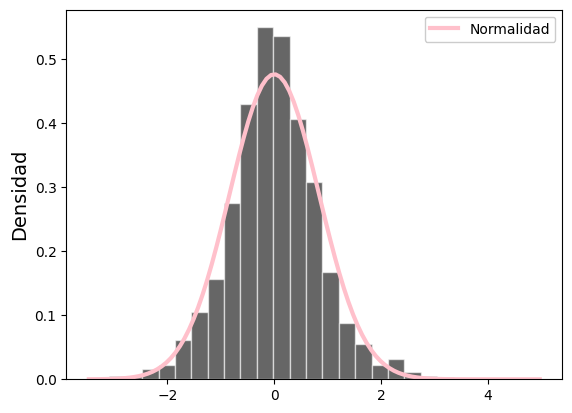

In [21]:
promedio, desviacion = stats.norm.fit(np.diff(vv_1h_ts_imputacion))

r = plt.hist(np.diff(vv_1h_ts_imputacion), bins = 25, alpha = 0.6, color = 'black',
         edgecolor = 'white', density = True)
         
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, promedio, desviacion)
no_print = plt.plot(x, p, 'pink', linewidth = 3, label = 'Normalidad')
no_print = plt.ylabel('Densidad', size = 14)
no_print = plt.legend(framealpha=1, frameon=True);

plt.show()

#### **qqnorm y qqline**

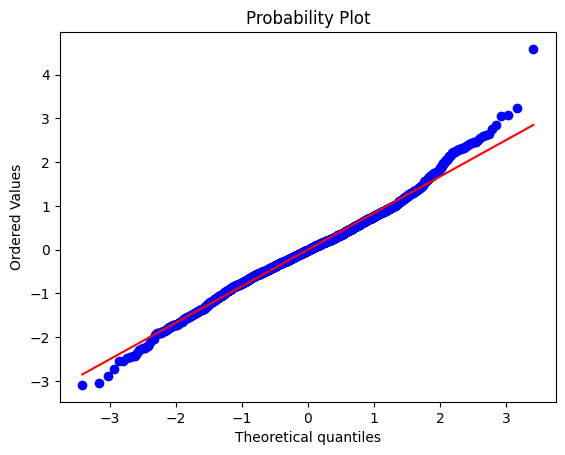

In [22]:
res = stats.probplot(np.diff(vv_1h_ts_imputacion), plot = plt)
plt.show()

#### **Test Normalidad**

In [23]:
def shapiro_test(data, alfa = 0.05):
    res = stats.shapiro(np.diff(data))
    print('p-value:', res[1])
    if res[1] >= alfa:
        print('Si p >= Alfa No se rechaza H0:\nLa muestra proviene de una distribución normal')
    else:
        print('Si P < Alfa Se rechaza H0:\nLa muestra no proviene de una distribución normal.')

In [24]:
shapiro_test(vv_1h_ts_imputacion)

p-value: 1.689309014392896e-11
Si P < Alfa Se rechaza H0:
La muestra no proviene de una distribución normal.


### Parte 5
- e) Convierta a serie de tiempo y realice una descomposición de la serie de tiempo.

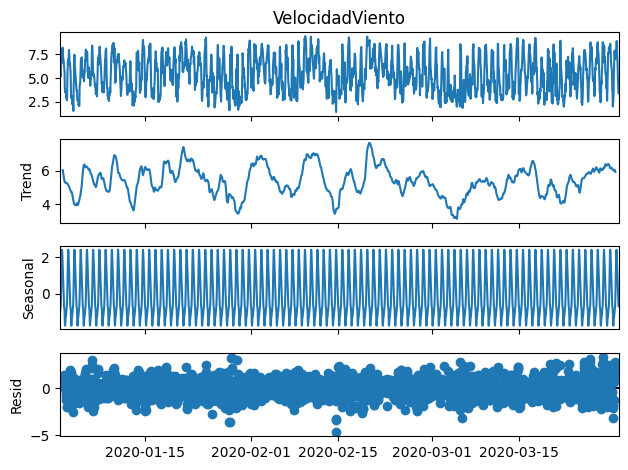

In [25]:
descomposicion = seasonal_decompose(
    vv_1h_ts_imputacion,
    model = 'additive',
    period = 24 # 24h = 1 día
)
descomposicion.plot()
plt.show()

### Parte 6
- f) Determine y grafique los periodos más importantes.

In [26]:
p_ts = Periodograma(vv_1h_ts_imputacion)

In [27]:
p_ts.mejor_freq(best=3)

array([0.04178273, 0.00464253, 0.00232126])

In [28]:
p_ts.mejor_periodos(best=3)

array([ 23.93333333, 215.4       , 430.8       ])

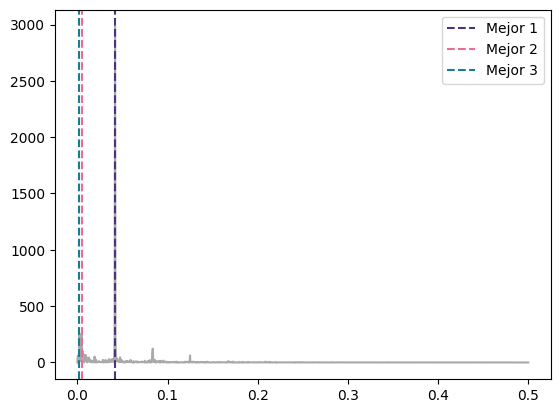

In [29]:
p_ts.plot_periodograma(best=3)

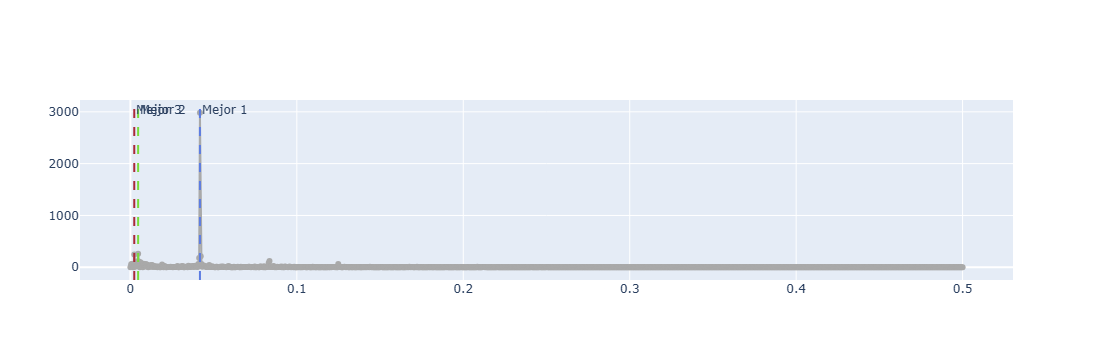

In [30]:
fig = p_ts.plotly_periodograma(best=3)
fig.show()

### Parte 7

- g) Usando 1 día para pruebas y el resto de fechas para entrenamiento genere modelos utilizando los métodos del `Promedio`, `Ingenuo`, `Estacional Ingenuo` y el de `Desvío`, luego grafique en un solo gráfico la serie de entrenamiento, la serie de prueba y el resultado de la predicción de cada uno de los modelos anteriores.

In [31]:
def train_test(serie_tiempo, test_size):
    test = serie_tiempo[-test_size:] # ultimos 12 meses para test
    train = serie_tiempo[:-test_size] # el resto menos 12 para train
    # print('Test:', len(test))
    # print('Train:', len(train))
    return {'train': train, 'test': test}

##### División train-test

In [32]:
test_train = train_test(vv_1h_ts_imputacion, test_size = 24) # 24 horas -> 1 dia
test_vv = test_train['test']
train_vv = test_train['train']

In [33]:
print('Train:', len(train_vv),'\nTest :', len(test_vv))

Train: 2130 
Test : 24


#### **Promedio**

In [34]:
metodo_mean_vv = meanf(train_vv)
pred_mean = metodo_mean_vv.fit()
pred_mean_ts = pred_mean.forecast(24)
pred_mean_ts[:5]

2020-03-30 00:00:00    5.400577
2020-03-30 01:00:00    5.400577
2020-03-30 02:00:00    5.400577
2020-03-30 03:00:00    5.400577
2020-03-30 04:00:00    5.400577
Freq: h, dtype: float64

#### **Ingenuo (Naïve)**

In [35]:
metodo_naive_vv = naive(train_vv)
pred_naive = metodo_naive_vv.fit()
pred_naive_ts = pred_naive.forecast(24)
pred_naive_ts[:5]

2020-03-30 00:00:00    3.852102
2020-03-30 01:00:00    3.852102
2020-03-30 02:00:00    3.852102
2020-03-30 03:00:00    3.852102
2020-03-30 04:00:00    3.852102
Freq: h, dtype: float64

#### **Método Estacional Ingenuo (Naïve)**

In [36]:
metodo_snaive_vv = snaive(train_vv)
pred_snaive = metodo_snaive_vv.fit(24) # mejor periodo encontrado en el periodograma, aprox
pred_snaive_ts = pred_snaive.forecast(24)
pred_snaive_ts[:5]

2020-03-30 00:00:00    3.943986
2020-03-30 01:00:00    4.270775
2020-03-30 02:00:00    4.099735
2020-03-30 03:00:00    2.623621
2020-03-30 04:00:00    3.469132
Freq: h, dtype: float64

#### **Desvío (Drift)**

In [37]:
metodo_drift_vv = drift(train_vv)
pred_drift = metodo_drift_vv.fit()
pred_drift_ts = pred_drift.forecast(24)
pred_drift_ts[:5]

2020-03-30 00:00:00    3.852102
2020-03-30 01:00:00    3.851142
2020-03-30 02:00:00    3.850182
2020-03-30 03:00:00    3.849222
2020-03-30 04:00:00    3.848263
Freq: h, dtype: float64

##### Graficar serie real y las predicciones en el Test

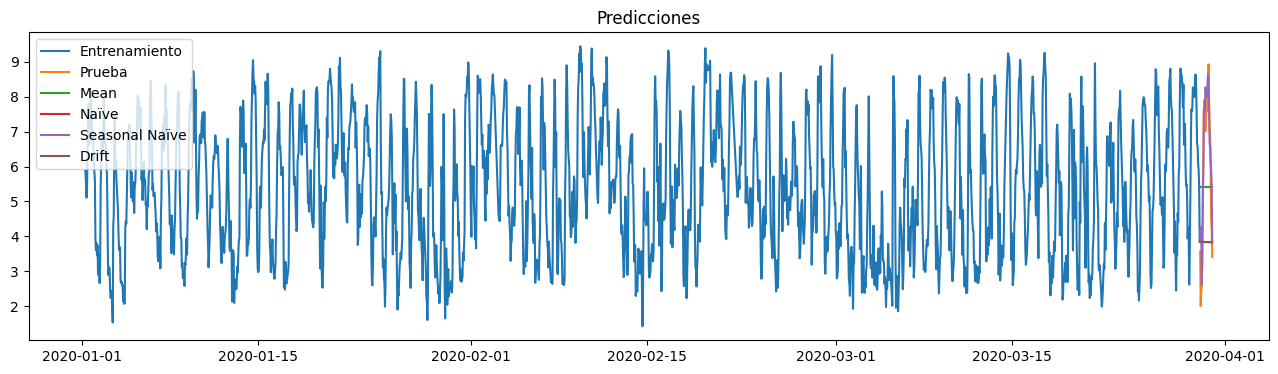

In [38]:
plt.figure(figsize=(16, 4))
aux = plt.plot(train_vv.index, train_vv.values, label = 'Entrenamiento')
aux = plt.plot(test_vv.index, test_vv.values, label = 'Prueba')

aux = plt.plot(pred_mean_ts.index, pred_mean_ts.values, label = 'Mean')
aux = plt.plot(pred_naive_ts.index, pred_naive_ts.values, label = 'Naïve')
aux = plt.plot(pred_snaive_ts.index, pred_snaive_ts.values, label = 'Seasonal Naïve')
aux = plt.plot(pred_drift_ts.index, pred_drift_ts.values, label = 'Drift')
aux = plt.legend(loc = 'best')
aux = plt.title("Predicciones")
plt.show()

In [39]:
# plt.figure(figsize=(16,6))

# plt.plot(train_vv[-72:], label='Entrenamiento')
# plt.plot(test_vv, label='Prueba')

# plt.plot(pred_mean_ts, label='Mean')
# plt.plot(pred_naive_ts, label='Naive')
# plt.plot(pred_snaive_ts, label='Seasonal Naive')
# plt.plot(pred_drift_ts, label='Drift')

# plt.legend()
# plt.show()

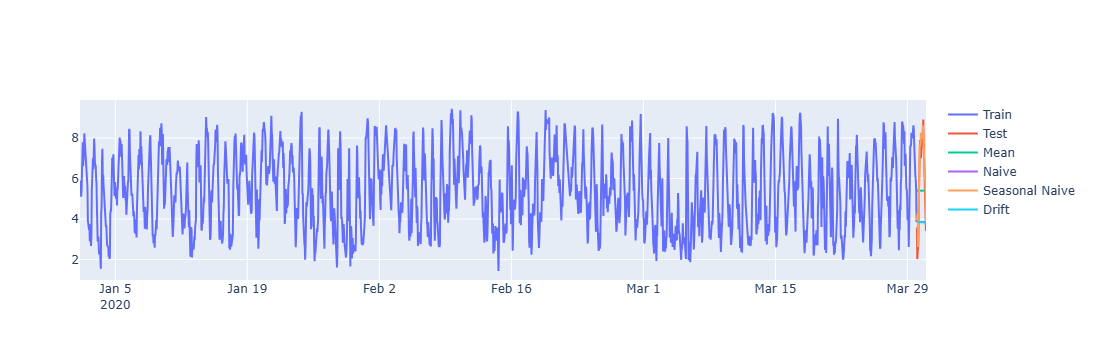

In [40]:
fig = go.Figure()

# train
no_plot = fig.add_trace(
    go.Scatter(x=train_vv.index.tolist(),y=train_vv.values.tolist(), mode = 'lines', #lines+markers
               name="Train"))

# test real
no_plot = fig.add_trace(
    go.Scatter(x=test_vv.index.tolist(),y=test_vv.values.tolist(), mode = 'lines',
               name="Test"))

# pred Mean
no_plot = fig.add_trace(
    go.Scatter(x=pred_mean_ts.index.tolist(),y=pred_mean_ts.values.tolist(), mode = 'lines',
               name="Mean"))

# pred Naive
no_plot = fig.add_trace(
    go.Scatter(x=pred_naive_ts.index.tolist(),y=pred_naive_ts.values.tolist(), mode = 'lines',
               name="Naive"))

# pred Seasonal Naive
no_plot = fig.add_trace(
    go.Scatter(x=pred_snaive_ts.index.tolist(),y=pred_snaive_ts.values.tolist(), mode = 'lines',
               name="Seasonal Naive"))

# pred drift
no_plot = fig.add_trace(
    go.Scatter(x=pred_drift_ts.index.tolist(),y=pred_drift_ts.values.tolist(), mode = 'lines',
               name="Drift"))

fig.show()

### Parte 8
- h) Con un gráfico mida el error y determine cuál modelo es el mejor.

In [41]:
# train_vv
# test_vv
# pred_mean_ts
# pred_naive_ts
# pred_snaive_ts
# pred_drift_ts

In [42]:
# errores = ts_error([pred_mean_ts, pred_naive_ts, pred_snaive_ts, pred_drift_ts], test_vv, ["Mean", "Naïve", "Seasonal Naïve", "Desvio"])
errores_vv = ts_error(
    preds = [
        pred_mean_ts,
        pred_naive_ts,
        pred_snaive_ts,
        pred_drift_ts
    ],
    real = test_vv,
    nombres = [
        'Mean',
        'Naïve',
        'Seasonal Naïve',
        'Drift'
    ]
)

In [43]:
errores_vv.df_errores()

,MSE,RMSE,RE,CORR
Mean,4.644437,2.155096,0.332696,-1.596147e-16
Naïve,8.710393,2.951337,0.433274,0.000000e+00
Seasonal Naïve,0.681895,0.825769,0.100743,9.406334e-01
Drift,8.766628,2.960849,0.434688,-3.604906e-01


En general, el método `Seasonal Naïve` presentó el mejor desempeño.  
Tiene el `MSE` (0.68) más bajo entre los otros 3 métodos, de igual forma se equivoca menos con `RMSE` de 0.83, un `RE` bastante más bajo y una `CORR` positiva fuerte de 0.94.

### Parte 9
- i) Con el mejor modelo encontrado en el punto anterior genere la predicción de un día, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

In [44]:
# 24h
metodo_snaive_vv_final = snaive(vv_1h_ts_imputacion)
pred_vv_final = metodo_snaive_vv_final.fit(24).forecast(24) # mejor periodo encontrado en el periodograma, aprox
pred_vv_final[:5]

2020-03-31 00:00:00    3.577046
2020-03-31 01:00:00    2.016962
2020-03-31 02:00:00    2.445339
2020-03-31 03:00:00    2.556242
2020-03-31 04:00:00    3.266401
Freq: h, dtype: float64

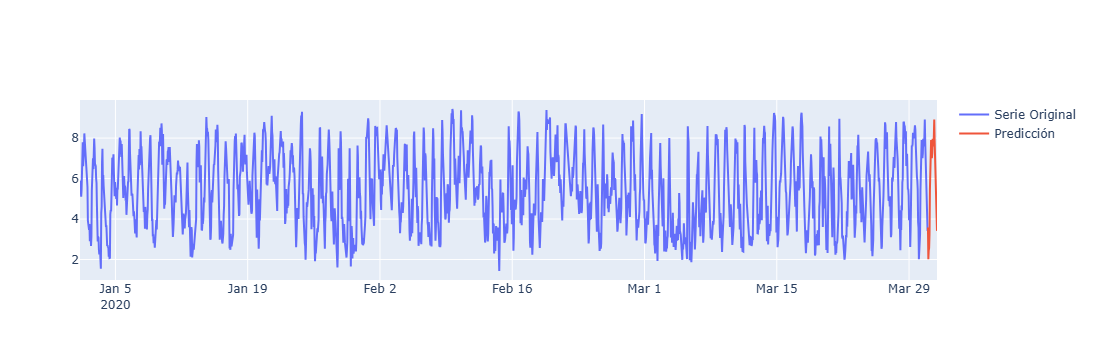

In [45]:
fig = go.Figure()

no_plot = fig.add_trace(
    go.Scatter(x=vv_1h_ts_imputacion.index.tolist(), y=vv_1h_ts_imputacion.values.tolist(), mode='lines', name='Serie Original'))

no_plot = fig.add_trace(
    go.Scatter(x=pred_vv_final.index.tolist(), y=pred_vv_final.values.tolist(), mode='lines', name='Predicción'))

fig.show()

<a id="ej2"></a>
# Ejercicio 2
[35 puntos] El archivo `emision_monetaria_CR.csv` contiene la emisión monetaria del BCCR
como saldos a fin de mes en millones de colones, desde enero de 1986 hasta marzo del 2026. Con la tabla realice lo siguiente:
- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).
- b) Realice un suavizado utilizando 3 datos (1 atrás y 1 adelante) y 7 datos (3 atrás y 3 adelante). Guarde ambos resultados en variables.
- c) Convierta a serie de tiempo los 3 sets de datos obtenidos en los puntos anteriores. Es decir, debe de generar 3 series de tiempo, una con un suavizado de 3, otra con un suavizado de 7 y la serie original.
- d) Utilizando 12 meses para pruebas y el resto de fechas para entrenamiento genere el modelo de `Estacional Ingenuo` para cada una de las series obtenidas, luego grafique en un solo gráfico la serie de entrenamiento, la serie de prueba (valor real) y el resultado de la
predicción de cada uno de los modelos.
- e) Con un gráfico mida el error y determine cuál modelo es el mejor.
- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de tres meses, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.


[↑ Volver al Menú](#menu)


### Preparación de los datos

In [46]:
emision_monetaria_cr = pd.read_csv('../../w1/h1/emision_monetaria_CR.csv')
emision_monetaria_cr

,Fecha,Valor
0,1986-01-01,12069.5
1,1986-02-01,12314.0
2,1986-03-01,12920.9
3,1986-04-01,12254.1
4,1986-05-01,12478.1
...,...,...
478,2025-11-01,1595905.1
479,2025-12-01,1625018.7
480,2026-01-01,1491267.8
481,2026-02-01,1471950.0


In [47]:
emision_monetaria_cr['Valor'] = emision_monetaria_cr['Valor'].astype('float64')
emision_monetaria_cr['Fecha'] = emision_monetaria_cr['Fecha'].astype('datetime64[ns]')

### Parte 1

- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).

In [48]:
emision = hay_fechas_faltantes(emision_monetaria_cr, col_name_date='Fecha', frequency='MS')

No, no hay valores faltantes en la columna 'Fecha'.


In [49]:
emision_monetaria_cr['Valor'].isnull().sum()

np.int64(0)

In [50]:
def to_serie_tiempo(datos, col_name_date, col_name_values, frequency): 
    df = datos.copy()
    fechas = pd.DatetimeIndex(df[col_name_date], freq = frequency)
    # ts_moneda = pd.Series(df[col_name_values].values, index = fechas)
    ts_moneda = pd.Series(
        data = df[col_name_values].values,
        index = fechas,
        name = col_name_values)
    return ts_moneda

### Parte 2

- b) Realice un suavizado utilizando 3 datos (1 atrás y 1 adelante) y 7 datos (3 atrás y 3 adelante). Guarde ambos resultados en variables.
- c) Convierta a serie de tiempo los 3 sets de datos obtenidos en los puntos anteriores. Es decir, debe de generar 3 series de tiempo, una con un suavizado de 3, otra con un suavizado de 7 y la serie original.

In [51]:
em_cr = to_serie_tiempo(emision_monetaria_cr, 'Fecha', 'Valor', frequency='MS')
em_cr[:10]

Fecha
1986-01-01    12069.5
1986-02-01    12314.0
1986-03-01    12920.9
1986-04-01    12254.1
1986-05-01    12478.1
1986-06-01    12610.6
1986-07-01    12517.3
1986-08-01    12895.6
1986-09-01    13124.8
1986-10-01    13582.8
Freq: MS, Name: Valor, dtype: float64

In [54]:
# función para rellenar las fechas faltantes, derivadas de la función anterior
def rellenar_fechas(datos, col_name_date, serie_completa):
    df = datos.copy()
    # asegurar datetime
    # df[col_name_date] = pd.to_datetime(df[col_name_date])
    df[col_name_date] = df[col_name_date].astype('datetime64[ns]')
    
    fechas_faltantes = [x for x in serie_completa if x not in df[col_name_date].to_list()]
    print('Primeras 5 filas:\n', fechas_faltantes[:5])
    
    completando_serie = pd.concat([df, pd.DataFrame({'Fecha': fechas_faltantes})], ignore_index = True) # Se añaden las fechas faltantes al final 
    completando_serie.sort_values(by = col_name_date, inplace = True) # Se ordenan las fechas de forma ascendente

    print('\nValores faltantes: ', completando_serie[col_name_date].isnull().sum())

    return completando_serie

In [55]:
def suavizado_movil(datos, size):
    df = datos.copy()
    suavizado = df.rolling(size, min_periods = 1, center = True).mean() # min_periods=1 para que no deje NaN al inicio y al final, center=True para que el promedio se centre en la ventana
    return suavizado

In [56]:
em_3 = suavizado_movil(em_cr, size=3)
em_3[:10]

Fecha
1986-01-01    12191.750000
1986-02-01    12434.800000
1986-03-01    12496.333333
1986-04-01    12551.033333
1986-05-01    12447.600000
1986-06-01    12535.333333
1986-07-01    12674.500000
1986-08-01    12845.900000
1986-09-01    13201.066667
1986-10-01    14045.433333
Freq: MS, Name: Valor, dtype: float64

In [57]:
em_7 = suavizado_movil(em_cr, size=7)
em_7[:10]

Fecha
1986-01-01    12389.625000
1986-02-01    12407.320000
1986-03-01    12441.200000
1986-04-01    12452.071429
1986-05-01    12570.085714
1986-06-01    12685.914286
1986-07-01    12780.471429
1986-08-01    13233.985714
1986-09-01    13923.757143
1986-10-01    14311.242857
Freq: MS, Name: Valor, dtype: float64

### Parte 3
- d) Utilizando 12 meses para pruebas y el resto de fechas para entrenamiento genere el modelo de `Estacional Ingenuo` para cada una de las series obtenidas, luego grafique en un solo gráfico la serie de entrenamiento, la serie de prueba (valor real) y el resultado de la predicción de cada uno de los modelos.
- e) Con un gráfico mida el error y determine cuál modelo es el mejor.
- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de tres meses, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

##### División train-test

In [58]:
test_train_orig = train_test(em_cr, test_size = 12)
test_orig = test_train_orig['test']
test_orig

Fecha
2025-04-01    1425876.6
2025-05-01    1383507.1
2025-06-01    1382265.4
2025-07-01    1437574.2
2025-08-01    1457363.2
2025-09-01    1448652.3
2025-10-01    1480524.1
2025-11-01    1595905.1
2025-12-01    1625018.7
2026-01-01    1491267.8
2026-02-01    1471950.0
2026-03-01    1503491.6
Freq: MS, Name: Valor, dtype: float64

In [59]:
train_orig = test_train_orig['train']
train_orig

Fecha
1986-01-01      12069.5
1986-02-01      12314.0
1986-03-01      12920.9
1986-04-01      12254.1
1986-05-01      12478.1
                ...    
2024-11-01    1526650.7
2024-12-01    1609543.0
2025-01-01    1463371.1
2025-02-01    1418118.9
2025-03-01    1386911.0
Freq: MS, Name: Valor, Length: 471, dtype: float64

In [60]:
print('Test:', len(test_orig))
print('Train:', len(train_orig))

Test: 12
Train: 471


In [61]:
test_train_3 = train_test(em_3, test_size = 12)
test_ts3 = test_train_3['test']
train_ts3 = test_train_3['train']

test_train_7 = train_test(em_7, test_size = 12)
test_ts7 = test_train_7['test']
train_ts7 = test_train_7['train']

#### **Método Estacional Ingenuo (Naïve)**

##### Generar Modelos Train

In [62]:
metodo_snaive_orig = snaive(train_orig)
metodo_snaive_ts3 = snaive(train_ts3)
metodo_snaive_ts7 = snaive(train_ts7)

##### Predecir en Test

In [63]:
pred_snaive_orig = metodo_snaive_orig.fit(12)
pred_snaive_ts_orig = pred_snaive_orig.forecast(12)
pred_snaive_ts_orig

2025-04-01    1314652.2
2025-05-01    1312797.0
2025-06-01    1321532.9
2025-07-01    1340276.9
2025-08-01    1379996.9
2025-09-01    1386373.3
2025-10-01    1420233.9
2025-11-01    1526650.7
2025-12-01    1609543.0
2026-01-01    1463371.1
2026-02-01    1418118.9
2026-03-01    1386911.0
Freq: MS, dtype: float64

In [64]:
pred_snaive_ts3 = metodo_snaive_ts3.fit(12)
pred_snaive_ts3 = pred_snaive_ts3.forecast(12)
pred_snaive_ts3

2025-04-01    1.334227e+06
2025-05-01    1.316327e+06
2025-06-01    1.324869e+06
2025-07-01    1.347269e+06
2025-08-01    1.368882e+06
2025-09-01    1.395535e+06
2025-10-01    1.444419e+06
2025-11-01    1.518809e+06
2025-12-01    1.533188e+06
2026-01-01    1.497011e+06
2026-02-01    1.422800e+06
2026-03-01    1.410302e+06
Freq: MS, dtype: float64

In [65]:
pred_snaive_ts7 = metodo_snaive_ts7.fit(12)
pred_snaive_ts7 = pred_snaive_ts7.forecast(12)
pred_snaive_ts7

2025-04-01    1.344135e+06
2025-05-01    1.342341e+06
2025-06-01    1.347266e+06
2025-07-01    1.353695e+06
2025-08-01    1.383980e+06
2025-09-01    1.426373e+06
2025-10-01    1.446635e+06
2025-11-01    1.457755e+06
2025-12-01    1.458743e+06
2026-01-01    1.464386e+06
2026-02-01    1.459140e+06
2026-03-01    1.438513e+06
Freq: MS, dtype: float64

##### Graficar serie real y las predicciones en el Test

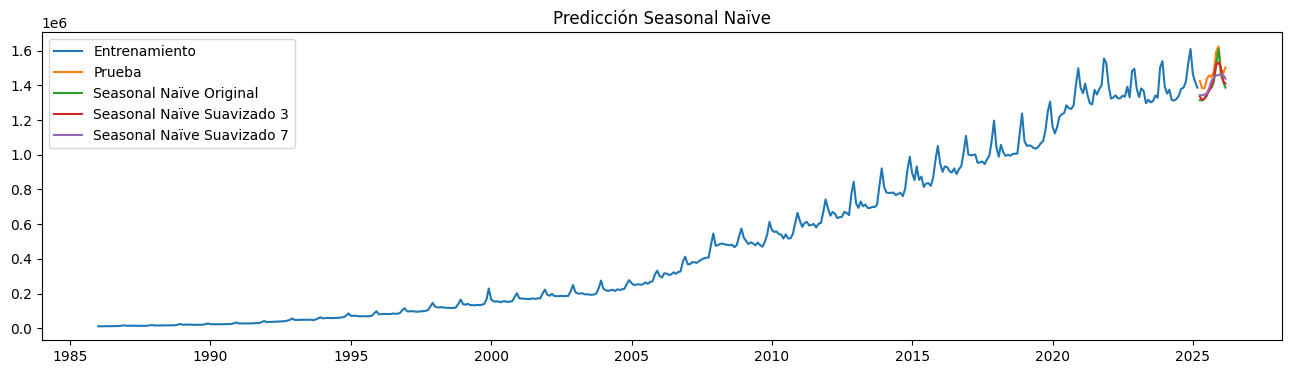

In [66]:
# aux = figsize = (12, 6)
plt.figure(figsize=(16, 4))
aux = plt.plot(train_orig.index, train_orig.values, label = 'Entrenamiento')
aux = plt.plot(test_orig.index, test_orig.values, label = 'Prueba')
aux = plt.plot(pred_snaive_ts_orig.index, pred_snaive_ts_orig.values, label = 'Seasonal Naïve Original')
aux = plt.plot(pred_snaive_ts3.index, pred_snaive_ts3.values, label = 'Seasonal Naïve Suavizado 3')
aux = plt.plot(pred_snaive_ts7.index, pred_snaive_ts7.values, label = 'Seasonal Naïve Suavizado 7')
aux = plt.legend(loc = 'best')
aux = plt.title("Predicción Seasonal Naïve")
plt.show()

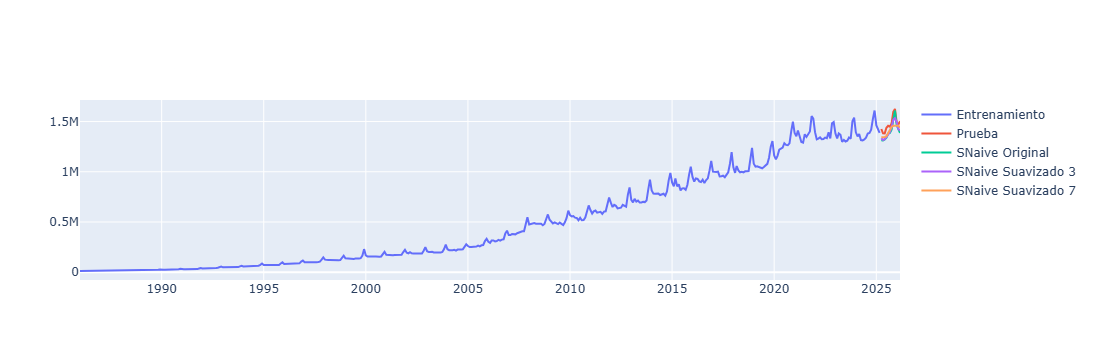

In [67]:
fig = go.Figure()

# train
no_plot = fig.add_trace(
    go.Scatter(x=train_orig.index.tolist(),y=train_orig.values.tolist(), mode = 'lines', #lines+markers
               name="Entrenamiento"))

# test real
no_plot = fig.add_trace(
    go.Scatter(x=test_orig.index.tolist(),y=test_orig.values.tolist(), mode = 'lines',
               name="Prueba"))

# pred orriginal
no_plot = fig.add_trace(
    go.Scatter(x=pred_snaive_ts_orig.index.tolist(),y=pred_snaive_ts_orig.values.tolist(), mode = 'lines',
               name="SNaive Original"))

# pred suavizado 3
no_plot = fig.add_trace(
    go.Scatter(x=pred_snaive_ts3.index.tolist(),y=pred_snaive_ts3.values.tolist(), mode = 'lines',
               name="SNaive Suavizado 3"))

# pred suavizado 7
no_plot = fig.add_trace(
    go.Scatter(x=pred_snaive_ts7.index.tolist(),y=pred_snaive_ts7.values.tolist(), mode = 'lines',
               name="SNaive Suavizado 7"))

fig.show()

##### Medición del Error en Test y Mejor modelo

In [68]:
errores = ts_error(
    preds = [
        pred_snaive_ts_orig,
        pred_snaive_ts3,
        pred_snaive_ts7
    ],
    real = test_orig,
    nombres = [
        'Original',
        'Suavizado 3',
        'Suavizado 7'
    ]
)

In [69]:
df_errores = errores.df_errores()
df_errores.style.format({
    'MSE': '{:,.2f}',
    'RMSE': '{:,.4f}',
    'RE': '{:.4f}',
    'CORR': '{:.4f}'
})

,MSE,RMSE,RE,CORR
Original,"5,527,319,306.50","74,345.9434",0.0465,0.9526
Suavizado 3,"5,152,129,756.91","71,778.3377",0.0453,0.9207
Suavizado 7,"6,292,400,515.16","79,324.6526",0.0441,0.7701


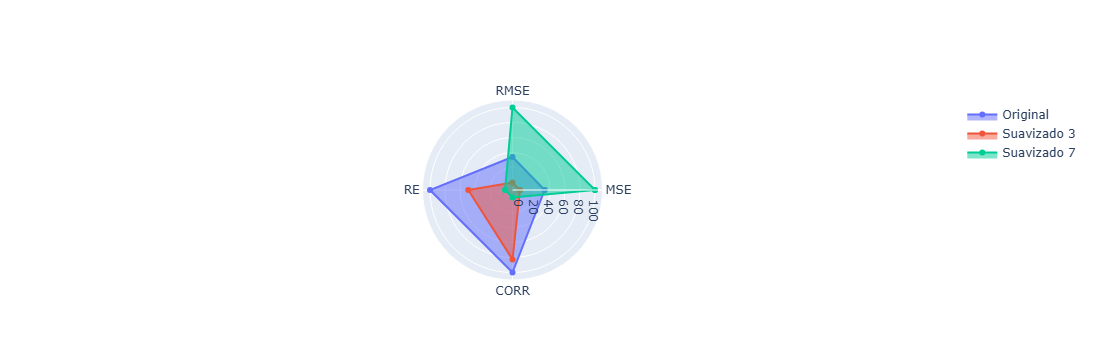

In [70]:
fig = errores.plotly_errores()
fig.show()

- MSE: El `Suavizado 3` (5,152,129,756.91) tuvo menores valores en comparacion con `Suavizado 7` (6,292,400,515.16) y `Original` (5,527,319,306.50).
- RMSE: En promedio el modelo `Suavizado 3` es el que se equivoca menos con 71,778.3 menor que `Suavizado 7` (79,324.6) y `Original` (74,345.9), o sea, que redujo el error.
- RE:`Suavizado 7`(0.0441) tuvo el mejor Error Relativo, aunque muy bajo CORR, pero tampoco se aleja tanto `Suavizado 3` (0.0453) y `Original` (0.0441).
- CORR: `Suavizado 3` (0.9207) y `Original` (0.9526) siguen la dinámica temporal muy bien, sin embargo `Suavizado 7` (0.7701) se desconecta con el valor real.

Entonces, en general el Modelo con Suavizado de 3 datos presentó el mejor desempeño, ya que obtuvo valores menores en MSE y RMSE además de mantener una correlacion alta con la serie real. Además tal y como se presenta en el gráfico `Suavizado 3`, es el más pequeño y más compacto.

##### Escoger el mejor método y realizar la predicción final

In [71]:
metodo_snaive_final = snaive(em_3)
pred_final = metodo_snaive_final.fit(h=12).forecast(3) # patron estacional de 12 meses, se predicen 3 meses
pred_final

2026-04-01    1.398765e+06
2026-05-01    1.397216e+06
2026-06-01    1.401116e+06
Freq: MS, dtype: float64

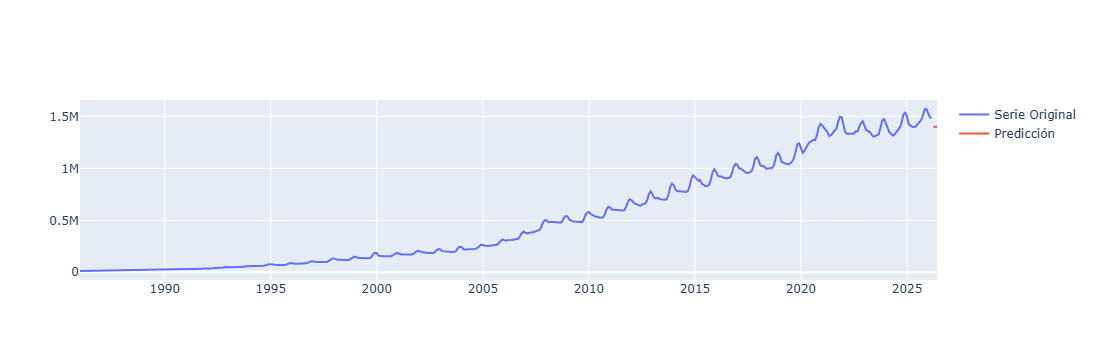

In [72]:
fig = go.Figure()

no_plot = fig.add_trace(
    go.Scatter(x=em_3.index.tolist(), y=em_3.values.tolist(), mode='lines', name='Serie Original'))

no_plot = fig.add_trace(
    go.Scatter(x=pred_final.index.tolist(), y=pred_final.values.tolist(), mode='lines', name='Predicción'))

fig.show()

<a id="ej3"></a>
# Ejercicio 3 
[35 puntos] La tabla `traficoweb_v1.csv` contiene la cantidad de usuarios que ingresan a una
determinada página web por día desde el 14 de setiembre del 2014 al 19 de agosto del 2020.
Con la tabla realice lo siguiente:
- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).
- b) Verifique la normalidad de la serie de tiempo. Puede probar solo de una forma.
- c) Convierta a serie de tiempo y realice una descomposición de la serie de tiempo.
- d) Usando las últimas 2 semanas para pruebas y el resto de fechas para entrenamiento genere los modelos de `Estacional Ingenuo` y el del `Desvío`, luego en un solo gráfico muestre la serie de entrenamiento, la serie de prueba y el resultado de la predicción de cada uno de los modelos anteriores.
- e) Con un gráfico mida el error y determine cuál modelo es el mejor.
- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de una semana, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

**NOTA: Toda conversión a serie de tiempo debe incluir la frecuencia correspondiente.**

[↑ Volver al Menú](#menu)

In [73]:
traficoweb = pd.read_csv('../../w1/h1/traficoweb_v1.csv', delimiter=';')
traficoweb

,Fecha,Visitas
0,9/14/2014,1582
1,9/15/2014,2528
2,9/16/2014,2630
3,9/17/2014,2614
4,9/18/2014,2366
...,...,...
2155,8/15/2020,1696
2156,8/16/2020,2037
2157,8/17/2020,2638
2158,8/18/2020,2683


In [74]:
traficoweb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Fecha    2160 non-null   object
 1   Visitas  2160 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.9+ KB


In [75]:
traficoweb['Fecha'] = traficoweb['Fecha'].astype('datetime64[ns]')
traficoweb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Fecha    2160 non-null   datetime64[ns]
 1   Visitas  2160 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 33.9 KB


### Parte 1
- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).

In [76]:
# recordar que esta funcion devuelve un dic con 'date_range' completo y 'faltantes' que son las fechas faltantes, si las hay.
trafico = hay_fechas_faltantes(traficoweb, col_name_date='Fecha', frequency='D')

Sí, hay fechas faltantes con una diferencia en la columna 'Fecha' de: -7


In [77]:
len(traficoweb)

2160

In [78]:
traficoweb['Visitas'].isnull().sum()

np.int64(0)

In [79]:
# cantidad total de fechas
len(trafico['date_range'])

2167

In [80]:
# rellnamos las fechas faltantes usando la funcion del ejercicio 2
traficoweb_relleno = rellenar_fechas(traficoweb, col_name_date='Fecha', serie_completa=trafico['date_range'])

Primeras 5 filas:
 [Timestamp('2014-10-01 00:00:00'), Timestamp('2015-04-28 00:00:00'), Timestamp('2018-07-09 00:00:00'), Timestamp('2019-09-21 00:00:00'), Timestamp('2019-12-22 00:00:00')]

Valores faltantes:  0


In [81]:
# pasamos a series de tiempo usando la funcion del ejercicio 2
# usamos los datos rellenados para no perder la continuidad de la serie de tiempo, los nombres de las cols y la frecuencia.
tw = to_serie_tiempo(traficoweb_relleno, col_name_date='Fecha', col_name_values='Visitas', frequency='D')
tw[:10]


Fecha
2014-09-14    1582.0
2014-09-15    2528.0
2014-09-16    2630.0
2014-09-17    2614.0
2014-09-18    2366.0
2014-09-19    1863.0
2014-09-20    1118.0
2014-09-21    1656.0
2014-09-22    2586.0
2014-09-23    3257.0
Freq: D, Name: Visitas, dtype: float64

In [82]:
tw_3_imputados = imputar_valores_faltantes_suavizados(traficoweb_relleno, col_name_values='Visitas', size=3, to_serie=True, frequency='D', col_name_date='Fecha')

Todos los valores faltantes fueron imputados con suavizado de 3 datos.


In [83]:
# len(tw_faltantes)
tw_3_imputados.isnull().sum()

np.int64(0)

In [84]:
tw_3_imputados[:10]

Fecha
2014-09-14    1582.0
2014-09-15    2528.0
2014-09-16    2630.0
2014-09-17    2614.0
2014-09-18    2366.0
2014-09-19    1863.0
2014-09-20    1118.0
2014-09-21    1656.0
2014-09-22    2586.0
2014-09-23    3257.0
Freq: D, Name: Visitas, dtype: float64

### Parte 2
- b) Verifique la normalidad de la serie de tiempo. Puede probar solo de una forma.

In [85]:
tw_diff = np.diff(tw_3_imputados)
tw_diff[:5]

array([ 946.,  102.,  -16., -248., -503.])

In [86]:
shapiro_test(tw_3_imputados)

p-value: 3.2143250884935276e-19
Si P < Alfa Se rechaza H0:
La muestra no proviene de una distribución normal.


### Parte 3
- c) Convierta a serie de tiempo y realice una descomposición de la serie de tiempo.

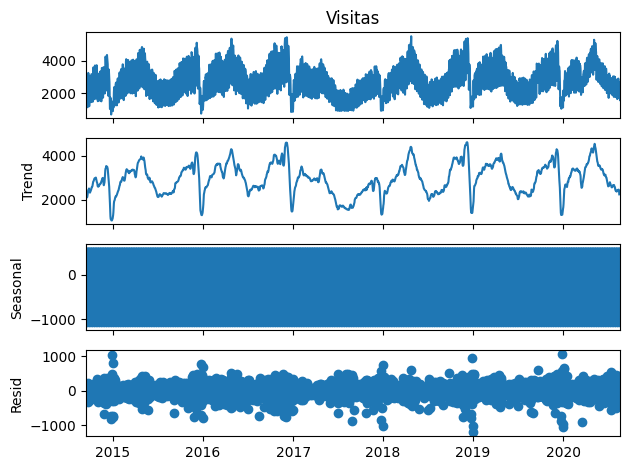

In [87]:
descomposicion = seasonal_decompose(
    tw_3_imputados,
    model='additive'
    # ,period=7
)
descomposicion.plot()
plt.show()

### Parte 4
- d) Usando las últimas 2 semanas para pruebas y el resto de fechas para entrenamiento genere los modelos de `Estacional Ingenuo` y el del `Desvío`, luego en un solo gráfico muestre la serie de entrenamiento, la serie de prueba y el resultado de la predicción de cada uno de los modelos anteriores.

##### División train-test

In [88]:
test_train_tw = train_test(tw_3_imputados, test_size=14)
train_tw = test_train_tw['train']
test_tw = test_train_tw['test']

In [89]:
print('train_tw:', len(train_tw),'\ntest_tw: ', len(test_tw))

train_tw: 2153 
test_tw:  14


##### **Método Estacional Ingenuo (Naïve)**

##### Generar Modelos Train

In [90]:
metodo_snaive_tw = snaive(train_tw)

##### Predecir en Test

In [91]:
fit_snaive_tw = metodo_snaive_tw.fit(14)
pred_snaive_tw = fit_snaive_tw.forecast(14)
pred_snaive_tw

2020-08-06    3033.0
2020-08-07    2623.0
2020-08-08    1767.0
2020-08-09    2207.0
2020-08-10    3031.0
2020-08-11    2969.0
2020-08-12    3010.0
2020-08-13    2687.0
2020-08-14    2317.0
2020-08-15    1750.0
2020-08-16    1993.0
2020-08-17    2419.0
2020-08-18    2845.0
2020-08-19    2774.0
Freq: D, dtype: float64

##### **Desvío (Drift)**

##### Predecir en Test

In [92]:
metodo_drift = drift(train_tw)
# metodo_drift

In [93]:
fit_drift = metodo_drift.fit()
pred_drift_tw = fit_drift.forecast(14) # promedio
pred_drift_tw

2020-08-06    2774.000000
2020-08-07    2774.553646
2020-08-08    2775.107292
2020-08-09    2775.660938
2020-08-10    2776.214584
2020-08-11    2776.768230
2020-08-12    2777.321876
2020-08-13    2777.875523
2020-08-14    2778.429169
2020-08-15    2778.982815
2020-08-16    2779.536461
2020-08-17    2780.090107
2020-08-18    2780.643753
2020-08-19    2781.197399
Freq: D, dtype: float64

##### Graficar serie real y las predicciones en el Test

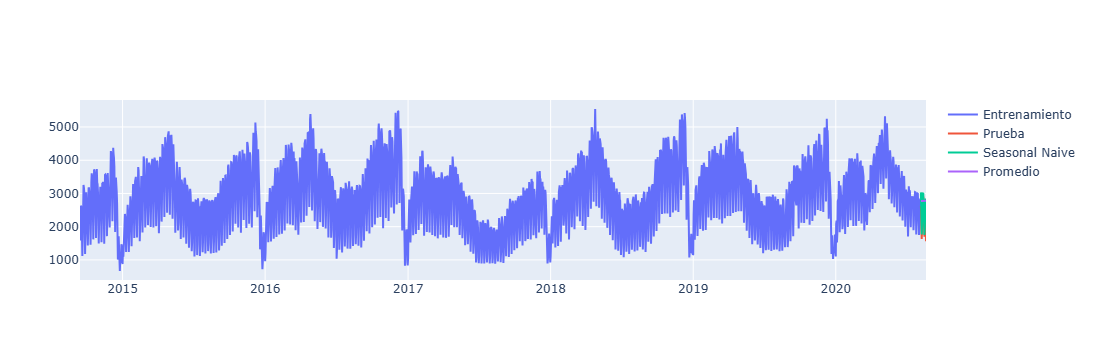

In [94]:
fig = go.Figure()

# train
no_plot = fig.add_trace(
    go.Scatter(x=train_tw.index.tolist(),y=train_tw.values.tolist(), mode = 'lines', #lines+markers
               name="Entrenamiento"))

# test real
no_plot = fig.add_trace(
    go.Scatter(x=test_tw.index.tolist(),y=test_tw.values.tolist(), mode = 'lines',
               name="Prueba"))

# pred seasonal naive
no_plot = fig.add_trace(
    go.Scatter(x=pred_snaive_tw.index.tolist(),y=pred_snaive_tw.values.tolist(), mode = 'lines',
               name="Seasonal Naive"))

# desvio drift
no_plot = fig.add_trace(
  go.Scatter(x = pred_drift_tw.index.tolist(), y = pred_drift_tw.values.tolist(), mode = 'lines',
             name = "Promedio"))

fig.show()

### Parte 5
- e) Con un gráfico mida el error y determine cuál modelo es el mejor.

##### Medición del Error en Test y Mejor modelo

In [95]:
errores_tw = ts_error(
    preds = [
        pred_snaive_tw,
        pred_drift_tw
    ],
    real = test_tw,
    nombres = [
        'Seasonal Naïve',
        'Drift',
    ]
)

In [96]:
errores_tw.df_errores()

,MSE,RMSE,RE,CORR
Seasonal Naïve,144290.714286,379.856176,0.106630,0.740194
Drift,405593.824460,636.862485,0.198713,-0.140004


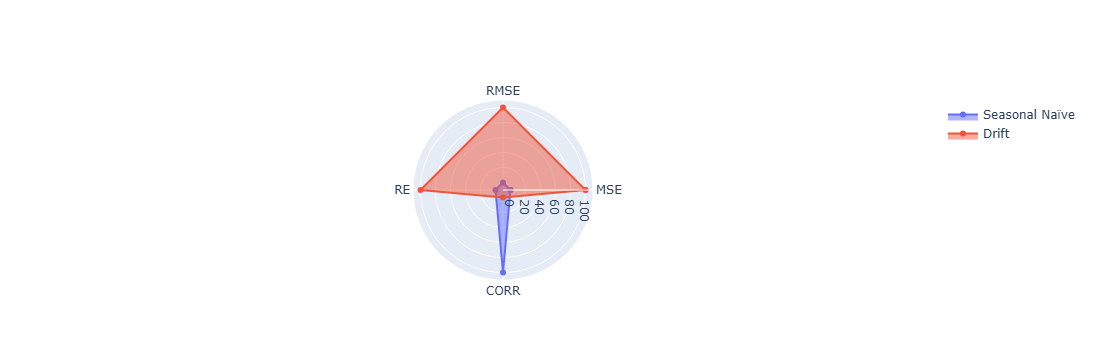

In [97]:
fig = errores_tw.plotly_errores()
fig.show()

El mejor método es el `Estacional Ingenuo (Naïve)`:
- `Estacional Ingenuo (Naïve)` (144290.71) tiene un MSE mucho menor al `Drift` (405593.82)
- En promedio se equivoca mucho menos (RSME) 379.85 vs 636.86
- Tiene un RE bastante mas bajo 10.6% vs 19.8%
- Tiene una correlación positiva fuerte, o sea que sigue el comportamiento de la serie, a diferencia del -0.14 con una realacion negativa, entonces este no sigue los movimientos reales.

### Parte 6
- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de una semana, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

In [98]:
# serie completa tw_3_imputados
mejor_metodo = snaive(tw_3_imputados)
pred_mejor = mejor_metodo.fit(h=7).forecast(7) #  patron estacional de 7 dias, se predicen 7 dias

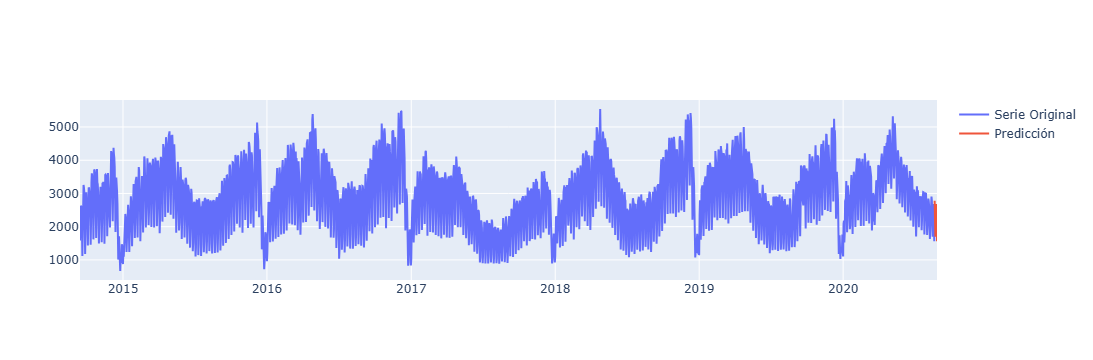

In [99]:
fig = go.Figure()

no_plot = fig.add_trace(
    go.Scatter(x=tw_3_imputados.index.tolist(), y=tw_3_imputados.values.tolist(), mode='lines', name='Serie Original'))

no_plot = fig.add_trace(
    go.Scatter(x=pred_mejor.index.tolist(), y=pred_mejor.values.tolist(), mode='lines', name='Predicción'))

fig.show()